<p align="center">
  <a href="https://github.com/wavekat/wavekat-lab">
    <img src="https://github.com/wavekat/wavekat-brand/raw/main/assets/banners/wavekat-lab-narrow.svg" alt="WaveKat Lab">
  </a>
</p>

# 06 — Upload two-model-agreed clips to the platform

Take the rows from `04c_models_agree.ipynb` (where our zh checkpoint and
pipecat-v3 agree on the label), rank them **pipecat-first, then ours**,
and post each one to the WaveKat platform as an auto-labelled annotation
with a `confidence` score.

The platform's records UI knows about `source = 'pre_labeled'` and a
per-row `confidence` (see `wavekat-platform/services/api/migrations/0012_annotation_confidence.sql`)
and lets a reviewer triage low-confidence rows first.

## What this notebook needs

1. A platform account with a project the upload should land in, and a
   label set on that project that defines `continuation` and
   `end_of_turn` keys (matching the binary labels we predict here).
2. A `wkcli_…` bearer token. The platform UI does **not** currently
   expose a manual "mint a token" button — tokens are issued through
   the `wk login` loopback flow:
   ```bash
   # Mint a token against your local platform:
   WK_BASE_URL=https://localhost:5020 wk login
   # …or against the deployed one:
   wk login   # defaults to https://platform.wavekat.com
   ```
   `wk login` opens your browser for GitHub auth, the platform mints
   the token, and the CLI persists it to
   `~/Library/Application Support/wavekat/auth.json` (macOS — see
   `wavekat-cli/src/config.rs:30` for the per-OS path).
3. A `.env` (alongside this repo's existing `.env`) with the token
   copied out of `auth.json`. Easiest one-liner:
   ```bash
   WAVEKAT_API_URL=https://localhost:5020
   WAVEKAT_API_TOKEN=$(jq -r .token "$HOME/Library/Application Support/wavekat/auth.json")
   WAVEKAT_PROJECT_ID=<paste from the platform UI>
   ```
   Make sure `WAVEKAT_API_URL` matches the host the token was minted
   against — a token issued by the local platform won't work against
   the production one and vice-versa.
4. The local MagicData-RAMC WAV files. The clip bytes are sliced from
   the same path that `04c` reads.

In [154]:
from __future__ import annotations

import hashlib
import io
import os
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import soundfile as sf
from tqdm.auto import tqdm

MINING_ROOT  = Path("../../datasets/smart-turn-zh-mining").resolve()
AGREED_IN    = MINING_ROOT / "candidates_models_agree.parquet"
WAV_DIR      = Path("../../datasets/MagicData-RAMC/MDT2021S003/WAV").resolve()

# Load WAVEKAT_* from a `.env` walking up from this notebook (same pattern
# as 05_score_llm.ipynb). `override=False` so an already-exported shell
# value wins over `.env`.
try:
    from dotenv import find_dotenv, load_dotenv
    dotenv_path = find_dotenv(usecwd=True)
    if dotenv_path:
        load_dotenv(dotenv_path, override=False)
        print(f"loaded .env  : {Path(dotenv_path).name} (from {Path(dotenv_path).parent.name}/)")
    else:
        print("loaded .env  : (none found — relying on shell environment)")
except ImportError:
    print("loaded .env  : (python-dotenv not installed — relying on shell environment)")

# Platform endpoint + auth. Default to the local dev URL so a wrong env
# var doesn't accidentally fire writes at production.
PLATFORM_BASE_URL = os.environ.get("WAVEKAT_API_URL", "https://localhost:5020").rstrip("/")
PLATFORM_TOKEN    = os.environ.get("WAVEKAT_API_TOKEN")
PROJECT_ID        = os.environ.get("WAVEKAT_PROJECT_ID")

# Cap the upload run. Default is large enough to cover the full agreed set
# (~couple of thousand rows). Set MAX_UPLOADS in the environment to a
# smaller number when you want a quick smoke test instead of a real run.
MAX_UPLOADS = int(os.environ.get("MAX_UPLOADS", "100000"))

# Map our binary {0, 1} labels to the platform label-set keys. The label
# set on the project must define exactly these keys for the create call to
# succeed.
LABEL_KEY_BY_PRED = {0: "continuation", 1: "end_of_turn"}

print(f"agreed parquet : {AGREED_IN.name} (exists={AGREED_IN.exists()})")
print(f"wav dir        : {WAV_DIR.name}/  (exists={WAV_DIR.exists()})")
print(f"platform       : {PLATFORM_BASE_URL}")
print(f"token set      : {bool(PLATFORM_TOKEN)}")
print(f"project id     : {PROJECT_ID or '(unset — set WAVEKAT_PROJECT_ID)'}")
print(f"max uploads    : {MAX_UPLOADS}")
print("✅ config loaded")

loaded .env  : .env (from wavekat-lab/)
agreed parquet : candidates_models_agree.parquet (exists=True)
wav dir        : WAV/  (exists=True)
platform       : https://platform.wavekat.com
token set      : True
project id     : 3040f61d-f6cb-4dd7-87e2-22b575d64a3c
max uploads    : 100000
✅ config loaded


In [155]:
# Ping /api/me — the cheapest possible "does my token work?" check.
# A 401 here means the token is wrong / revoked / minted against a
# different platform host (e.g. token from prod, URL pointing at local).
# Run this on its own first; only continue if it returns your login.
if not PLATFORM_TOKEN:
    raise SystemExit("WAVEKAT_API_TOKEN is unset — mint one with `wk login --base-url …` and export it.")

session = requests.Session()
session.headers.update({
    "Authorization": f"Bearer {PLATFORM_TOKEN}",
    "User-Agent": "wavekat-lab/06-upload-notebook",
})

me = session.get(f"{PLATFORM_BASE_URL}/api/me", timeout=10)
if me.status_code == 401:
    raise SystemExit(
        f"401 from {PLATFORM_BASE_URL}/api/me — token rejected.\n"
        f"  • Was the token minted against this host? (tokens are scoped to a single platform.)\n"
        f"  • Has it been revoked? Mint a fresh one: `WK_BASE_URL={PLATFORM_BASE_URL} wk login`."
    )
me.raise_for_status()
me_json = me.json()
print(f"authenticated as : {me_json.get('login')}  (role={me_json.get('role')}, id={me_json.get('id')})")
print("✅ token works")

authenticated as : wavekat-eason  (role=root, id=220911746)
✅ token works


In [156]:
# Verify the destination project + its active label set. Split out from the
# /me ping so a project-config issue doesn't masquerade as an auth failure.
if not PROJECT_ID:
    raise SystemExit("WAVEKAT_PROJECT_ID is unset — set it to the destination project's id.")

proj = session.get(f"{PLATFORM_BASE_URL}/api/projects/{PROJECT_ID}", timeout=10)
if proj.status_code == 404:
    raise SystemExit(
        f"404 on project {PROJECT_ID} — either the id is wrong, or your account "
        f"isn't a member of that project (the API returns 404, not 403, to avoid leaking existence)."
    )
proj.raise_for_status()
proj_json = proj.json()
print(f"project          : {proj_json.get('name')}  (role={proj_json.get('myRoleInProject')})")
active_label_set_id = proj_json.get("activeLabelSetId")
if not active_label_set_id:
    raise SystemExit("project has no active label set — pick one in the platform UI first.")

ls = session.get(f"{PLATFORM_BASE_URL}/api/label-sets/{active_label_set_id}", timeout=10)
ls.raise_for_status()
ls_json = ls.json()
label_keys = {l["key"] for l in ls_json.get("labels", [])}
missing = set(LABEL_KEY_BY_PRED.values()) - label_keys
if missing:
    raise SystemExit(
        f"active label set '{ls_json.get('name')}' is missing required keys: {sorted(missing)}"
    )
print(f"label set        : {ls_json.get('name')}  (keys: {sorted(label_keys)})")
print("✅ project + label set verified")

project          : MagicData-RAMC - Auto Label #3  (role=root)
label set        : Turn Detection V1  (keys: ['continuation', 'end_of_turn'])
✅ project + label set verified


In [157]:
# Build the upload pool from 04c's agreed rows. Two stages:
#
# 1. Band filter (this cell) — restrict to a confidence band.
#    Confidence is the joint probability under both models for the
#    chosen label:
#      EOT  : P(EOT|pipecat)  * P(EOT|ours)  = pipecat_prob       * model_prob
#      CONT : P(CONT|pipecat) * P(CONT|ours) = (1 - pipecat_prob) * (1 - model_prob)
#    Treating the two votes as independent collapses to a single [0, 1]
#    number that the records-UI confidence column can rank by. Default
#    band is [0.0, 1.0] (everything); tighten to e.g. [0.5, 0.6] when
#    you want to focus on the borderline strip.
#
# 2. Stratified sample (next cell) — turn the band into a fixed-size,
#    duration-stratified, label-balanced upload queue.
agreed = pd.read_parquet(AGREED_IN)

pp = agreed["pipecat_prob"].astype(float)
mp = agreed["model_prob"].astype(float)
is_eot = agreed["model_pred"] == 1
agreed["confidence"] = np.where(is_eot, pp * mp, (1.0 - pp) * (1.0 - mp))
agreed["duration_s"] = (agreed["clip_end_s"] - agreed["clip_start_s"]).astype(float)

CONFIDENCE_MIN = float(os.environ.get("CONFIDENCE_MIN", "0.0"))
CONFIDENCE_MAX = float(os.environ.get("CONFIDENCE_MAX", "1.0"))
in_band = (agreed["confidence"] >= CONFIDENCE_MIN) & (agreed["confidence"] <= CONFIDENCE_MAX)
banded = agreed[in_band].copy()

print(f"agreed rows total : {len(agreed)}")
print(f"confidence band   : [{CONFIDENCE_MIN:.3f}, {CONFIDENCE_MAX:.3f}]  "
      f"(env: CONFIDENCE_MIN, CONFIDENCE_MAX)")
print(f"rows in band      : {len(banded)}")
print("  by label:")
for pred, label_key in sorted(LABEL_KEY_BY_PRED.items()):
    n = int((banded["model_pred"] == pred).sum())
    print(f"    {label_key:>12} : {n}")
print("✅ band filter applied — proceed to the sampling cell")

agreed rows total : 21811
confidence band   : [0.100, 1.000]  (env: CONFIDENCE_MIN, CONFIDENCE_MAX)
rows in band      : 21811
  by label:
    continuation : 6444
     end_of_turn : 15367
✅ band filter applied — proceed to the sampling cell


In [158]:
# Stratified sample: fill each duration bucket's budget with a balanced
# split when possible, and spill onto the other label when one side is
# sparse — so the per-bucket *budget* is hit even when per-bucket
# *balance* can't be.
#
# Logic:
#   1. Bin every banded row into a duration bucket (same edges the
#      records-UI duration filter uses, so the chart and the platform
#      tell the same story).
#   2. Each bucket gets a budget proportional to its share of the in-band
#      pool — TARGET_TOTAL * (rows_in_bucket / rows_in_band). So if the
#      <1s bucket holds 10% of the pool and TARGET_TOTAL=1000, that
#      bucket's budget is 100.
#   3. Ideal split: each label gets `budget // num_labels` from that
#      bucket, taken as the top-N by confidence DESC.
#   4. Spill: if a label can't fill its share (e.g. only 18 `continuation`
#      rows in the 5–8s bucket when 50 were asked), the shortfall plus
#      the floor-division remainder is handed to the labels that still
#      have capacity — also taken top-N by confidence DESC. Strict
#      per-bucket label balance is sacrificed in exchange for hitting
#      the bucket's overall budget.
TARGET_TOTAL = int(os.environ.get("TARGET_TOTAL", "100"))

DURATION_EDGES  = [0.0, 1.0, 2.0, 3.0, 5.0, 8.0, 10.0, float("inf")]
DURATION_LABELS = ["<1s", "1–2s", "2–3s", "3–5s", "5–8s", "8–10s", "≥10s"]

banded["duration_bucket"] = pd.cut(
    banded["duration_s"], bins=DURATION_EDGES, labels=DURATION_LABELS, right=False,
).astype(str)

bucket_pool_counts = (
    banded["duration_bucket"]
    .value_counts()
    .reindex(DURATION_LABELS, fill_value=0)
)
total_in_band = int(bucket_pool_counts.sum())
num_labels = len(LABEL_KEY_BY_PRED)

plan_rows = []
sampled_parts: list[pd.DataFrame] = []
for bucket in DURATION_LABELS:
    pool = int(bucket_pool_counts[bucket])
    proportion = (pool / total_in_band) if total_in_band else 0.0
    target_bucket = int(round(TARGET_TOTAL * proportion))
    target_per_label = target_bucket // num_labels  # ideal balanced share

    bucket_df = banded[banded["duration_bucket"] == bucket]
    avail_per_label: dict[int, int] = {}
    ranked: dict[int, pd.DataFrame] = {}
    for pred in sorted(LABEL_KEY_BY_PRED):
        cell = (
            bucket_df[bucket_df["model_pred"] == pred]
            .sort_values("confidence", ascending=False, kind="mergesort")
        )
        avail_per_label[pred] = len(cell)
        ranked[pred] = cell

    # Phase 1: ideal balanced allocation, capped at each label's availability.
    take = {pred: min(target_per_label, avail_per_label[pred]) for pred in avail_per_label}
    # Phase 2: any leftover budget (per-label shortfall + the floor-division
    # remainder) spills onto whichever labels still have capacity, in
    # descending order of remaining capacity. With 2 labels this means
    # the abundant side absorbs the gap; with N labels it spreads.
    gap = target_bucket - sum(take.values())
    for pred in sorted(
        avail_per_label, key=lambda p: avail_per_label[p] - take[p], reverse=True
    ):
        if gap <= 0:
            break
        capacity = avail_per_label[pred] - take[pred]
        add = min(gap, capacity)
        take[pred] += add
        gap -= add

    for pred, cell in ranked.items():
        sampled_parts.append(cell.head(take[pred]))

    row = {
        "bucket":           bucket,
        "pool":             pool,
        "share%":           round(100 * proportion, 1),
        "budget":           target_bucket,
        "per_label_target": target_per_label,
    }
    for pred, label_key in sorted(LABEL_KEY_BY_PRED.items()):
        row[f"avail_{label_key}"] = avail_per_label[pred]
    for pred, label_key in sorted(LABEL_KEY_BY_PRED.items()):
        row[f"take_{label_key}"] = take[pred]
    row["bucket_actual"] = sum(take.values())
    plan_rows.append(row)

plan_df = pd.DataFrame(plan_rows)
sampled = (
    pd.concat(sampled_parts, ignore_index=True) if sampled_parts else banded.iloc[0:0]
)

# Round-robin interleave so a partial run still spreads labels: when the
# shorter queue runs out, the longer one continues solo to the end.
parts = []
for label_idx, pred in enumerate(sorted(LABEL_KEY_BY_PRED)):
    q = (
        sampled[sampled["model_pred"] == pred]
        .sort_values("confidence", ascending=False, kind="mergesort")
        .reset_index(drop=True)
        .copy()
    )
    q["_round"] = np.arange(len(q))
    q["_label_idx"] = label_idx
    parts.append(q)
to_upload = (
    pd.concat(parts, ignore_index=True)
    .sort_values(["_round", "_label_idx"], kind="mergesort")
    .drop(columns=["_round", "_label_idx"])
    .reset_index(drop=True)
    .head(MAX_UPLOADS)
    .reset_index(drop=True)
)

print(f"target total      : {TARGET_TOTAL}  (env: TARGET_TOTAL)")
print(f"sampled total     : {len(to_upload)}  (cap MAX_UPLOADS={MAX_UPLOADS})")
print("by label (queued):")
for pred, label_key in sorted(LABEL_KEY_BY_PRED.items()):
    n = int((to_upload["model_pred"] == pred).sum())
    print(f"    {label_key:>12} : {n}")
if len(to_upload):
    print(f"confidence range  : "
          f"min={to_upload['confidence'].min():.3f}, "
          f"median={to_upload['confidence'].median():.3f}, "
          f"max={to_upload['confidence'].max():.3f}")
print("\nper-bucket plan:")
display(plan_df)
print("✅ stratified sample built — review the plan + chart before uploading")

target total      : 100  (env: TARGET_TOTAL)
sampled total     : 100  (cap MAX_UPLOADS=100000)
by label (queued):
    continuation : 50
     end_of_turn : 50
confidence range  : min=0.529, median=0.613, max=0.643

per-bucket plan:


,bucket,pool,share%,budget,per_label_target,avail_continuation,avail_end_of_turn,take_continuation,take_end_of_turn,bucket_actual
0,<1s,0,0.0,0,0,0,0,0,0,0
1,1–2s,8001,36.7,37,18,4401,3600,19,18,37
2,2–3s,5862,26.9,27,13,1581,4281,13,14,27
3,3–5s,5695,26.1,26,13,444,5251,13,13,26
4,5–8s,2186,10.0,10,5,18,2168,5,5,10
5,8–10s,67,0.3,0,0,0,67,0,0,0
6,≥10s,0,0.0,0,0,0,0,0,0,0


✅ stratified sample built — review the plan + chart before uploading


In [148]:
# Targeted pick: override `to_upload` with a single label + duration window
# (+ optional ASR-text filters), ranked by `PICK_ORDER`. Use this when
# you want to focus a review batch (e.g. "give me 50 end_of_turn clips
# between 1.5–2s, with ASR text containing '?'") instead of the
# stratified sample above. Skip / don't run this cell if you want the
# stratified plan from the previous cell to drive the upload.
import secrets

PICK_LABEL         = os.environ.get("PICK_LABEL", "continuation")           # "end_of_turn" or "continuation"
PICK_DURATION_MIN  = float(os.environ.get("PICK_DURATION_MIN", "4.0"))
PICK_DURATION_MAX  = float(os.environ.get("PICK_DURATION_MAX", "5.0"))
PICK_COUNT         = int(os.environ.get("PICK_COUNT", "50"))

# Which confidence score to attach to the upload + use for ordering.
#   "pipecat" : pipecat-only:  P(label|pipecat).  Default — pipecat-v3 is
#               the stronger of the two votes, so its calibration is
#               what reviewers should triage by.
#   "ours"    : ours-only:     P(label|ours).
#   "mix"     : joint probability under both models (treats the two
#               votes as independent so both must be confident).
# Whichever is picked here overwrites the `confidence` column on the
# upload queue, so the platform's per-row confidence reflects this choice.
PICK_CONFIDENCE    = os.environ.get("PICK_CONFIDENCE", "pipecat").lower()

# Ordering of the pool before head(PICK_COUNT).
#   "random"          : uniform random sample from the pool, seeded by
#                       PICK_SEED for reproducibility (default — when
#                       PICK_SEED is unset we mint a fresh random seed
#                       each run so successive picks don't collide with
#                       already-uploaded rows; set PICK_SEED in the env
#                       to make a run reproducible).
#   "confidence_desc" : highest-confidence first (best for seeding the
#                       platform with strong examples). Uses the
#                       PICK_CONFIDENCE score above.
#   "confidence_asc"  : lowest-confidence first (borderline triage).
PICK_ORDER         = os.environ.get("PICK_ORDER", "random").lower()
_pick_seed_env     = os.environ.get("PICK_SEED", "").strip()
PICK_SEED          = int(_pick_seed_env) if _pick_seed_env else secrets.randbits(32)
PICK_SEED_SOURCE   = "env" if _pick_seed_env else "auto"

# ASR-text filters. All optional, all combinable.
#   PICK_TEXT_REQUIRED  : "yes" → row must have non-empty asr text
#                         "no"  → row must have empty asr text
#                         "any" → don't filter on presence (default)
#   PICK_TEXT_CONTAINS  : comma-separated substrings; row's text must
#                         contain at least one (case-insensitive). Empty
#                         string disables this filter.
#   PICK_TEXT_EXCLUDES  : comma-separated substrings; row's text must
#                         contain NONE of these (case-insensitive). Empty
#                         string disables this filter.
PICK_TEXT_REQUIRED = os.environ.get("PICK_TEXT_REQUIRED", "any").lower()
PICK_TEXT_CONTAINS = os.environ.get("PICK_TEXT_CONTAINS", "")
PICK_TEXT_EXCLUDES = os.environ.get("PICK_TEXT_EXCLUDES", "就是")

PRED_BY_LABEL_KEY = {v: k for k, v in LABEL_KEY_BY_PRED.items()}
if PICK_LABEL not in PRED_BY_LABEL_KEY:
    raise SystemExit(f"PICK_LABEL must be one of {sorted(PRED_BY_LABEL_KEY)} (got {PICK_LABEL!r})")
if PICK_TEXT_REQUIRED not in {"yes", "no", "any"}:
    raise SystemExit(f"PICK_TEXT_REQUIRED must be 'yes' | 'no' | 'any' (got {PICK_TEXT_REQUIRED!r})")
VALID_ORDERS = {"confidence_desc", "confidence_asc", "random"}
if PICK_ORDER not in VALID_ORDERS:
    raise SystemExit(f"PICK_ORDER must be one of {sorted(VALID_ORDERS)} (got {PICK_ORDER!r})")
VALID_CONFIDENCES = {"mix", "pipecat", "ours"}
if PICK_CONFIDENCE not in VALID_CONFIDENCES:
    raise SystemExit(f"PICK_CONFIDENCE must be one of {sorted(VALID_CONFIDENCES)} (got {PICK_CONFIDENCE!r})")
pick_pred = PRED_BY_LABEL_KEY[PICK_LABEL]

contains_terms = [t.strip().lower() for t in PICK_TEXT_CONTAINS.split(",") if t.strip()]
excludes_terms = [t.strip().lower() for t in PICK_TEXT_EXCLUDES.split(",") if t.strip()]

# Pull from `agreed` (not `banded`) so this cell is independent of the
# confidence-band filter above — the targeted pick has its own ranking.
text_lc = agreed["text"].fillna("").astype(str).str.lower()
has_text = text_lc.str.len() > 0

in_window = (
    (agreed["model_pred"] == pick_pred)
    & (agreed["duration_s"] >= PICK_DURATION_MIN)
    & (agreed["duration_s"] <  PICK_DURATION_MAX)
)
if PICK_TEXT_REQUIRED == "yes":
    in_window &= has_text
elif PICK_TEXT_REQUIRED == "no":
    in_window &= ~has_text
if contains_terms:
    # OR across terms — any one match is enough.
    contains_mask = np.zeros(len(agreed), dtype=bool)
    for t in contains_terms:
        contains_mask |= text_lc.str.contains(t, regex=False).to_numpy()
    in_window &= contains_mask
if excludes_terms:
    # AND across terms — every term must be absent.
    for t in excludes_terms:
        in_window &= ~text_lc.str.contains(t, regex=False).to_numpy()

pool = agreed[in_window].copy()

# Recompute the `confidence` column to match PICK_CONFIDENCE — overrides
# the joint score from the band-filter cell so ordering, the chart, the
# preview, and the platform's per-row confidence all use the same number.
pp = pool["pipecat_prob"].astype(float)
mp = pool["model_prob"].astype(float)
is_eot_pool = pool["model_pred"] == 1
if PICK_CONFIDENCE == "pipecat":
    pool["confidence"] = np.where(is_eot_pool, pp, 1.0 - pp)
elif PICK_CONFIDENCE == "ours":
    pool["confidence"] = np.where(is_eot_pool, mp, 1.0 - mp)
else:  # mix
    pool["confidence"] = np.where(is_eot_pool, pp * mp, (1.0 - pp) * (1.0 - mp))

if PICK_ORDER == "confidence_desc":
    pool = pool.sort_values("confidence", ascending=False, kind="mergesort")
elif PICK_ORDER == "confidence_asc":
    pool = pool.sort_values("confidence", ascending=True,  kind="mergesort")
else:  # random — sample without replacement, capped at pool size
    n = min(PICK_COUNT, len(pool))
    pool = pool.sample(n=n, random_state=PICK_SEED) if n else pool
to_upload = pool.head(PICK_COUNT).reset_index(drop=True).head(MAX_UPLOADS).reset_index(drop=True)

print(f"pick label        : {PICK_LABEL}  (env: PICK_LABEL)")
print(f"pick duration     : [{PICK_DURATION_MIN:.2f}s, {PICK_DURATION_MAX:.2f}s)  (env: PICK_DURATION_MIN, PICK_DURATION_MAX)")
print(f"pick count        : {PICK_COUNT}  (env: PICK_COUNT)")
print(f"pick confidence   : {PICK_CONFIDENCE}  (env: PICK_CONFIDENCE)")
print(f"pick order        : {PICK_ORDER}"
      f"{f' (seed={PICK_SEED}, source={PICK_SEED_SOURCE})' if PICK_ORDER == 'random' else ''}"
      f"  (env: PICK_ORDER, PICK_SEED)")
print(f"text required     : {PICK_TEXT_REQUIRED}  (env: PICK_TEXT_REQUIRED)")
print(f"text contains     : {contains_terms or '(none)'}  (env: PICK_TEXT_CONTAINS)")
print(f"text excludes     : {excludes_terms or '(none)'}  (env: PICK_TEXT_EXCLUDES)")
print(f"pool in window    : {int(in_window.sum())}")
print(f"queued for upload : {len(to_upload)}")
if len(to_upload) < PICK_COUNT:
    print(f"⚠️  pool only had {int(in_window.sum())} rows — queue is short of the {PICK_COUNT} requested")
if len(to_upload):
    print(f"confidence range  : "
          f"min={to_upload['confidence'].min():.3f}, "
          f"median={to_upload['confidence'].median():.3f}, "
          f"max={to_upload['confidence'].max():.3f}")
    print(f"duration range    : "
          f"min={to_upload['duration_s'].min():.3f}s, "
          f"max={to_upload['duration_s'].max():.3f}s")
    n_with_text = int((to_upload["text"].fillna("").astype(str).str.len() > 0).sum())
    print(f"with asr text     : {n_with_text} / {len(to_upload)}")
print("✅ targeted pick built — overrides `to_upload` for the chart + upload cells below")

pick label        : continuation  (env: PICK_LABEL)
pick duration     : [4.00s, 5.00s)  (env: PICK_DURATION_MIN, PICK_DURATION_MAX)
pick count        : 50  (env: PICK_COUNT)
pick confidence   : pipecat  (env: PICK_CONFIDENCE)
pick order        : random (seed=1419744293, source=auto)  (env: PICK_ORDER, PICK_SEED)
text required     : any  (env: PICK_TEXT_REQUIRED)
text contains     : (none)  (env: PICK_TEXT_CONTAINS)
text excludes     : ['就是']  (env: PICK_TEXT_EXCLUDES)
pool in window    : 32
queued for upload : 32
⚠️  pool only had 32 rows — queue is short of the 50 requested
confidence range  : min=0.520, median=0.989, max=0.995
duration range    : min=4.000s, max=4.829s
with asr text     : 32 / 32
✅ targeted pick built — overrides `to_upload` for the chart + upload cells below


In [168]:
# Raw-source pick: bypass model agreement entirely. Pulls from the raw
# `candidates.parquet` (output of 03_build_candidates) and filters by
# label / duration / ASR text. Useful for seeding the platform with
# examples derived directly from RAMC's gold segmentation, with no
# model vote attached. Like the targeted-pick cell above, this cell
# overrides `to_upload` for the chart + preview + upload cells below.
# Skip / don't run this cell if you want one of the model-driven flows.
import secrets

RAW_IN = MINING_ROOT / "candidates.parquet"

# Filters.
#   RAW_LABEL          : "any" | "end_of_turn" | "continuation". When
#                        "any", the budget is split evenly between the
#                        two labels (with spillover onto the abundant
#                        side if one is sparse).
#   RAW_DURATION_MIN/MAX : half-open [min, max) window in seconds.
#   RAW_COUNT          : total rows to queue for upload.
#   RAW_CONFIDENCE     : flat confidence written to every queued row.
#                        Defaults to 0.5 — neutral, surfaces these rows
#                        to the middle of the records-UI triage list so
#                        a reviewer actually looks at them. Bump to 1.0
#                        if you want them treated as gold-grade.
#   RAW_ORDER          : "random" (default) | "duration_asc" | "duration_desc".
#                        No model score to rank by, so order is either
#                        random (with PICK_SEED-style auto seed) or
#                        duration-based.
#   RAW_TEXT_REQUIRED/CONTAINS/EXCLUDES : same semantics as the
#                        targeted-pick cell above.
RAW_LABEL          = os.environ.get("RAW_LABEL", "continuation").lower()
RAW_DURATION_MIN   = float(os.environ.get("RAW_DURATION_MIN", "8.0"))
RAW_DURATION_MAX   = float(os.environ.get("RAW_DURATION_MAX", "810.0"))
RAW_COUNT          = int(os.environ.get("RAW_COUNT", "50"))
RAW_CONFIDENCE     = float(os.environ.get("RAW_CONFIDENCE", "0.5"))
RAW_ORDER          = os.environ.get("RAW_ORDER", "random").lower()
_raw_seed_env      = os.environ.get("RAW_SEED", "").strip()
RAW_SEED           = int(_raw_seed_env) if _raw_seed_env else secrets.randbits(32)
RAW_SEED_SOURCE    = "env" if _raw_seed_env else "auto"
RAW_TEXT_REQUIRED  = os.environ.get("RAW_TEXT_REQUIRED", "any").lower()
RAW_TEXT_CONTAINS  = os.environ.get("RAW_TEXT_CONTAINS", "")
RAW_TEXT_EXCLUDES  = os.environ.get("RAW_TEXT_EXCLUDES", "")

VALID_RAW_LABELS = {"any"} | set(LABEL_KEY_BY_PRED.values())
if RAW_LABEL not in VALID_RAW_LABELS:
    raise SystemExit(f"RAW_LABEL must be one of {sorted(VALID_RAW_LABELS)} (got {RAW_LABEL!r})")
if RAW_TEXT_REQUIRED not in {"yes", "no", "any"}:
    raise SystemExit(f"RAW_TEXT_REQUIRED must be 'yes' | 'no' | 'any' (got {RAW_TEXT_REQUIRED!r})")
VALID_RAW_ORDERS = {"random", "duration_asc", "duration_desc"}
if RAW_ORDER not in VALID_RAW_ORDERS:
    raise SystemExit(f"RAW_ORDER must be one of {sorted(VALID_RAW_ORDERS)} (got {RAW_ORDER!r})")

raw = pd.read_parquet(RAW_IN)
raw["duration_s"] = (raw["clip_end_s"] - raw["clip_start_s"]).astype(float)
# `label` in candidates.parquet is the gold-derived 0/1 from RAMC's
# segmentation (intra_utterance_cut → continuation, speaker_change →
# end_of_turn). Reuse it as `model_pred` so the chart + preview + upload
# cells below — which key off `model_pred` — work unchanged.
raw["model_pred"] = raw["label"].astype(int)

contains_terms = [t.strip().lower() for t in RAW_TEXT_CONTAINS.split(",") if t.strip()]
excludes_terms = [t.strip().lower() for t in RAW_TEXT_EXCLUDES.split(",") if t.strip()]
text_lc = raw["text"].fillna("").astype(str).str.lower()
has_text = text_lc.str.len() > 0

mask = (raw["duration_s"] >= RAW_DURATION_MIN) & (raw["duration_s"] < RAW_DURATION_MAX)
if RAW_LABEL != "any":
    pred_for_label = {v: k for k, v in LABEL_KEY_BY_PRED.items()}[RAW_LABEL]
    mask &= raw["model_pred"] == pred_for_label
if RAW_TEXT_REQUIRED == "yes":
    mask &= has_text
elif RAW_TEXT_REQUIRED == "no":
    mask &= ~has_text
if contains_terms:
    contains_mask = np.zeros(len(raw), dtype=bool)
    for t in contains_terms:
        contains_mask |= text_lc.str.contains(t, regex=False).to_numpy()
    mask &= contains_mask
if excludes_terms:
    for t in excludes_terms:
        mask &= ~text_lc.str.contains(t, regex=False).to_numpy()

pool = raw[mask].copy()


def _draw(df: pd.DataFrame, n: int) -> pd.DataFrame:
    if n <= 0 or df.empty:
        return df.iloc[0:0]
    if RAW_ORDER == "duration_asc":
        return df.sort_values("duration_s", ascending=True, kind="mergesort").head(n)
    if RAW_ORDER == "duration_desc":
        return df.sort_values("duration_s", ascending=False, kind="mergesort").head(n)
    return df.sample(n=min(n, len(df)), random_state=RAW_SEED)


if RAW_LABEL == "any":
    half = RAW_COUNT // 2
    parts = []
    for pred in sorted(LABEL_KEY_BY_PRED):
        cell = pool[pool["model_pred"] == pred]
        parts.append(_draw(cell, half))
    drawn = pd.concat(parts, ignore_index=False) if parts else pool.iloc[0:0]
    # Spill any shortfall (e.g. one label sparse in this window) onto the
    # remaining rows so RAW_COUNT is hit when the pool can support it.
    gap = RAW_COUNT - len(drawn)
    if gap > 0:
        rest = pool.drop(index=drawn.index, errors="ignore")
        drawn = pd.concat([drawn, _draw(rest, gap)], ignore_index=False)
    drawn = drawn.reset_index(drop=True)
else:
    drawn = _draw(pool, RAW_COUNT).reset_index(drop=True)

drawn["confidence"]   = float(RAW_CONFIDENCE)
# `model_prob` / `pipecat_prob` aren't meaningful here — set to NaN so
# the upload cell below can detect the raw path and write a different
# notes string. The upload cell falls back to the agreement-style notes
# only when `_notes` is empty, so we set it explicitly here.
drawn["model_prob"]   = float("nan")
drawn["pipecat_prob"] = float("nan")
drawn["_notes"] = drawn.apply(
    lambda r: (
        "smart-turn-mining raw candidate (no model vote)\n"
        f"source={r['source']}, gold_label={int(r['label'])}, "
        f"duration={float(r['duration_s']):.2f}s"
    ),
    axis=1,
)

to_upload = drawn.head(MAX_UPLOADS).reset_index(drop=True)

print(f"raw parquet       : {RAW_IN.name}  (rows: {len(raw)})")
print(f"label filter      : {RAW_LABEL}  (env: RAW_LABEL)")
print(f"duration window   : [{RAW_DURATION_MIN:.2f}s, {RAW_DURATION_MAX:.2f}s)  (env: RAW_DURATION_MIN, RAW_DURATION_MAX)")
print(f"count target      : {RAW_COUNT}  (env: RAW_COUNT)")
print(f"order             : {RAW_ORDER}"
      f"{f' (seed={RAW_SEED}, source={RAW_SEED_SOURCE})' if RAW_ORDER == 'random' else ''}"
      f"  (env: RAW_ORDER, RAW_SEED)")
print(f"confidence        : {RAW_CONFIDENCE}  (env: RAW_CONFIDENCE — uniform, no model vote)")
print(f"text required     : {RAW_TEXT_REQUIRED}  (env: RAW_TEXT_REQUIRED)")
print(f"text contains     : {contains_terms or '(none)'}  (env: RAW_TEXT_CONTAINS)")
print(f"text excludes     : {excludes_terms or '(none)'}  (env: RAW_TEXT_EXCLUDES)")
print(f"pool in window    : {int(mask.sum())}")
print(f"queued for upload : {len(to_upload)}")
if len(to_upload) < RAW_COUNT:
    print(f"⚠️  pool only had {int(mask.sum())} rows — queue is short of the {RAW_COUNT} requested")
if len(to_upload):
    print("by label (queued):")
    for pred, label_key in sorted(LABEL_KEY_BY_PRED.items()):
        n = int((to_upload["model_pred"] == pred).sum())
        print(f"    {label_key:>12} : {n}")
    print(f"duration range    : "
          f"min={to_upload['duration_s'].min():.3f}s, "
          f"max={to_upload['duration_s'].max():.3f}s")
print("✅ raw-source pick built — overrides `to_upload` for the chart + upload cells below")


raw parquet       : candidates.parquet  (rows: 33943)
label filter      : continuation  (env: RAW_LABEL)
duration window   : [8.00s, 810.00s)  (env: RAW_DURATION_MIN, RAW_DURATION_MAX)
count target      : 50  (env: RAW_COUNT)
order             : random (seed=3960144641, source=auto)  (env: RAW_ORDER, RAW_SEED)
confidence        : 0.5  (env: RAW_CONFIDENCE — uniform, no model vote)
text required     : any  (env: RAW_TEXT_REQUIRED)
text contains     : (none)  (env: RAW_TEXT_CONTAINS)
text excludes     : (none)  (env: RAW_TEXT_EXCLUDES)
pool in window    : 7
queued for upload : 7
⚠️  pool only had 7 rows — queue is short of the 50 requested
by label (queued):
    continuation : 7
     end_of_turn : 0
duration range    : min=8.000s, max=8.000s
✅ raw-source pick built — overrides `to_upload` for the chart + upload cells below


queued clips     : 7
duration min     : 8.000s
duration p50     : 8.000s
duration p90     : 8.000s
duration p99     : 8.000s
duration max     : 8.000s
✅ all clips ≤ 8s — match the model's input window and the platform's bucketing


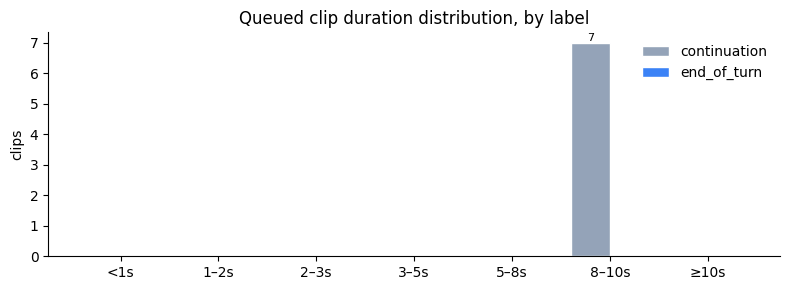

✅ duration distribution preview — run the upload cell when satisfied


In [169]:
# Pre-flight chart: clip-duration distribution of the queued sample,
# split by label. Buckets line up with the records-UI duration filter on
# the platform so the chart and the UI tell the same story. Use this to
# eyeball that the sample mirrors the in-band pool's duration shape;
# per-bucket label balance is best-effort — when one label is sparse in
# a bucket, the sampler spills the gap onto the abundant label so the
# bucket's overall budget is still hit.
import matplotlib.pyplot as plt

durations = (to_upload["clip_end_s"] - to_upload["clip_start_s"]).astype(float)
print(f"queued clips     : {len(durations)}")
if len(durations):
    print(f"duration min     : {durations.min():.3f}s")
    print(f"duration p50     : {durations.median():.3f}s")
    print(f"duration p90     : {durations.quantile(0.90):.3f}s")
    print(f"duration p99     : {durations.quantile(0.99):.3f}s")
    print(f"duration max     : {durations.max():.3f}s")

n_over_8 = int((durations > 8.0).sum())
if n_over_8:
    print(f"⚠️  {n_over_8} clip(s) exceed 8s — the platform's duration filter "
          f"will lump these into its ≥10s bucket")
elif len(durations):
    print("✅ all clips ≤ 8s — match the model's input window and the platform's bucketing")

# Per-label histogram: paired bars per bucket so balance is obvious.
counts_by_label: dict[str, np.ndarray] = {}
for pred, label_key in sorted(LABEL_KEY_BY_PRED.items()):
    sub = to_upload[to_upload["model_pred"] == pred]
    d = (sub["clip_end_s"] - sub["clip_start_s"]).astype(float)
    c, _ = np.histogram(d, bins=DURATION_EDGES)
    counts_by_label[label_key] = c

fig, ax = plt.subplots(figsize=(8, 3.0))
x = np.arange(len(DURATION_LABELS))
w = 0.4
palette = {"continuation": "#94a3b8", "end_of_turn": "#3b82f6"}
for i, (label_key, c) in enumerate(counts_by_label.items()):
    offset = (i - (len(counts_by_label) - 1) / 2) * w
    bars = ax.bar(x + offset, c, w, label=label_key,
                  color=palette.get(label_key), edgecolor="white")
    for bar, v in zip(bars, c):
        if v:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f"{int(v)}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(DURATION_LABELS)
ax.set_ylabel("clips")
ax.set_title("Queued clip duration distribution, by label")
ax.legend(loc="upper right", frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()
print("✅ duration distribution preview — run the upload cell when satisfied")

In [170]:
# Per-session helpers: hash the WAV once (the platform dedupes by
# sha256), and remember the file row id so we don't refetch on every
# clip. The `files` POST is idempotent so a re-run is cheap, but a single
# session yields 50+ clips — caching keeps the run snappy.
import functools

_HASH_CHUNK = 1024 * 1024  # 1 MB — keep memory bounded for large session WAVs.

@functools.lru_cache(maxsize=None)
def session_wav_meta(session_id: str) -> dict:
    path = WAV_DIR / f"{session_id}.wav"
    info = sf.info(str(path))
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(_HASH_CHUNK)
            if not chunk:
                break
            h.update(chunk)
    return {
        "path": path,
        "sha256": h.hexdigest(),
        "sample_rate": int(info.samplerate),
        "channels": int(info.channels),
        "duration_sec": float(info.frames) / float(info.samplerate),
    }

@functools.lru_cache(maxsize=None)
def upsert_file(session_id: str) -> str:
    """Create-or-get the platform `files` row for a session WAV; return its id."""
    meta = session_wav_meta(session_id)
    body = {
        "name": session_id,
        "originalFilename": f"{session_id}.wav",
        "sha256": meta["sha256"],
        "durationSec": meta["duration_sec"],
        "sampleRate": meta["sample_rate"],
        "channelCount": meta["channels"],
    }
    r = session.post(
        f"{PLATFORM_BASE_URL}/api/projects/{PROJECT_ID}/files",
        json=body, timeout=15,
    )
    r.raise_for_status()
    j = r.json()
    return j["id"]

def slice_wav_bytes(session_id: str, start_s: float, end_s: float) -> bytes:
    """Read [start_s, end_s) from the source WAV and re-emit a 16-bit PCM
    WAV blob. Mono-mixes the source so the clip stays small and the
    server-side WAV-meta parse stays in the supported codec list."""
    meta = session_wav_meta(session_id)
    sr = meta["sample_rate"]
    start  = max(0, int(start_s * sr))
    frames = max(1, int((end_s - start_s) * sr))
    audio, _ = sf.read(str(meta["path"]), start=start, frames=frames,
                       dtype="float32", always_2d=False)
    if audio.ndim == 2:
        audio = audio.mean(axis=1)
    buf = io.BytesIO()
    sf.write(buf, audio, sr, format="WAV", subtype="PCM_16")
    return buf.getvalue()

print("✅ helpers ready")

✅ helpers ready


In [171]:
# Preview the first N rows of `to_upload` as inline audio players — the
# last sanity check before firing the upload loop. Uses the same
# `slice_wav_bytes` the upload cell uses, so what you hear is exactly
# what gets PUT to /api/annotations/{id}/clip.
from IPython.display import Audio, display, HTML

PREVIEW_N = int(os.environ.get("PREVIEW_N", "10"))
preview = to_upload.head(PREVIEW_N)
print(f"previewing {len(preview)} of {len(to_upload)} queued clips  (env: PREVIEW_N)")

for i, row in preview.iterrows():
    sid = str(row["session_id"])
    pred = int(row["model_pred"])
    label_key = LABEL_KEY_BY_PRED[pred]
    start_s = float(row["clip_start_s"])
    end_s   = float(row["clip_end_s"])
    asr_text = str(row.get("text", "") or "")
    wav_bytes = slice_wav_bytes(sid, start_s, end_s)
    header = (
        f"[{i + 1:02d}] {label_key}  "
        f"conf={float(row['confidence']):.3f}  "
        f"dur={end_s - start_s:.2f}s  "
        f"{sid} @ {start_s:.2f}–{end_s:.2f}s"
    )
    display(HTML(f"<div style='font-family:ui-monospace,monospace;font-size:12px;margin-top:6px'>{header}</div>"))
    if asr_text:
        display(HTML(f"<div style='font-size:13px;color:#475569;margin-bottom:2px'>asr: {asr_text}</div>"))
    display(Audio(data=wav_bytes))
print("✅ preview rendered — scroll up to listen, then run the upload cell when satisfied")

previewing 7 of 7 queued clips  (env: PREVIEW_N)


✅ preview rendered — scroll up to listen, then run the upload cell when satisfied


In [172]:
# Upload loop. Each row: ensure the session file exists on the platform,
# create the annotation row with source=pre_labeled + confidence, then
# PUT the sliced WAV bytes. Two HTTP round-trips per clip — at ~1 RPS
# each that's ~5 hours for the full agreed set, so we parallelise the
# per-clip work with a thread pool. Network-I/O bound, so threads scale
# fine; results come back in submission order via `executor.map`.
#
# Range is `[clip_start_s, clip_end_s]` straight from the parquet — the
# same slice that 04c plays in its audio embeds and that the model scored
# on. `clip_start_s` is already snapped to the parent utterance's start
# (or `clip_end_s - 8s`, whichever is later) by 03_build_candidates, so
# no widening here.
import concurrent.futures
from requests.adapters import HTTPAdapter

# Bump the Session's connection pool above the default 10 so worker
# threads don't queue on a single shared HTTPS connection. requests.Session
# is safe for concurrent use once the pool is sized for the workers.
_adapter = HTTPAdapter(pool_connections=64, pool_maxsize=64, max_retries=0)
session.mount("https://", _adapter)
session.mount("http://", _adapter)

# Pre-warm `upsert_file` for every unique session WAV. The slow part is
# the local SHA-256 hash of the source WAV; doing it once up-front keeps
# the upload threads from all racing to hash the same file (lru_cache
# only memoises *after* the first call returns).
unique_sessions = sorted(set(to_upload["session_id"].astype(str)))
print(f"pre-warming {len(unique_sessions)} session file(s)…")
with concurrent.futures.ThreadPoolExecutor(max_workers=4) as _ex:
    list(tqdm(_ex.map(upsert_file, unique_sessions),
              total=len(unique_sessions), desc="files", unit="file"))

UPLOAD_WORKERS = int(os.environ.get("UPLOAD_WORKERS", "16"))


def _upload_one(row_tuple):
    _, row = row_tuple
    sid = str(row["session_id"])
    pred = int(row["model_pred"])
    label_key = LABEL_KEY_BY_PRED[pred]
    confidence = float(row["confidence"])
    start_s = float(row["clip_start_s"])
    end_s   = float(row["clip_end_s"])
    asr_text = str(row.get("text", "") or "")[:4000]

    try:
        file_id = upsert_file(sid)
        # Raw-source pick sets `_notes` per row; the agreement and
        # targeted-pick flows leave it unset, so fall back to the
        # model-prob notes.
        notes_override = row.get("_notes")
        if isinstance(notes_override, str) and notes_override:
            notes = notes_override
        else:
            notes = (
                f"smart-turn-mining 04c agreement\n"
                f"ours_prob={float(row['model_prob']):.4f}, "
                f"pipecat_prob={float(row['pipecat_prob']):.4f}, "
                f"gold_label={row.get('label')}"
            )
        create_body = {
            "labelKey":   label_key,
            "startSec":   start_s,
            "endSec":     end_s,
            "asrText":    asr_text or None,
            "source":     "pre_labeled",
            "confidence": confidence,
            "notes":      notes,
        }
        r = session.post(
            f"{PLATFORM_BASE_URL}/api/files/{file_id}/annotations",
            json=create_body, timeout=30,
        )
        r.raise_for_status()
        ann_id = r.json()["id"]

        wav_bytes = slice_wav_bytes(sid, start_s, end_s)
        u = session.put(
            f"{PLATFORM_BASE_URL}/api/annotations/{ann_id}/clip",
            data=wav_bytes,
            headers={"Content-Type": "audio/wav"},
            timeout=60,
        )
        u.raise_for_status()
        return {
            "ok": True, "annotation_id": ann_id, "label": label_key,
            "confidence": confidence, "bytes": len(wav_bytes),
            "session": sid, "range": f"{start_s:.2f}-{end_s:.2f}",
        }
    except requests.HTTPError as e:
        body = getattr(e.response, "text", "")
        return {
            "ok": False, "label": label_key, "confidence": confidence,
            "session": sid, "range": f"{start_s:.2f}-{end_s:.2f}",
            "error": f"HTTP {e.response.status_code}: {body[:200]}",
        }
    except Exception as e:
        return {
            "ok": False, "label": label_key, "confidence": confidence,
            "session": sid, "range": f"{start_s:.2f}-{end_s:.2f}",
            "error": f"{type(e).__name__}: {e}",
        }


results: list[dict] = []
ok_count = 0
fail_count = 0

rows = list(to_upload.iterrows())
pbar = tqdm(total=len(rows), desc="upload", unit="clip")
with concurrent.futures.ThreadPoolExecutor(max_workers=UPLOAD_WORKERS) as ex:
    # `executor.map` preserves submission order and the iteration runs in
    # the main thread, so appending to `results` doesn't need a lock.
    for res in ex.map(_upload_one, rows):
        results.append(res)
        if res["ok"]:
            ok_count += 1
        else:
            fail_count += 1
        pbar.set_postfix(ok=ok_count, fail=fail_count, refresh=False)
        pbar.update(1)
pbar.close()

results_df = pd.DataFrame(results)
print(f"uploaded ok : {ok_count}")
print(f"failed      : {fail_count}  (workers={UPLOAD_WORKERS})")
if fail_count:
    # Surface the first few failures inline — much easier than hunting
    # through a 1000-row results_df for the broken ones.
    print("\nfirst failures:")
    display(results_df[~results_df["ok"]].head(5))
print("✅ upload run complete")
results_df.head(20)


pre-warming 4 session file(s)…


files:   0%|          | 0/4 [00:00<?, ?file/s]

upload:   0%|          | 0/7 [00:00<?, ?clip/s]

uploaded ok : 7
failed      : 0  (workers=16)
✅ upload run complete


,ok,annotation_id,label,confidence,bytes,session,range
0,True,e06fdcc4-965d-4281-97b2-b93c2b2fff8e,continuation,0.5,256044,CTS-CN-F2F-2019-11-15-165,1301.44-1309.44
1,True,cc577115-7fc1-43a4-8ccc-062515d6e0bc,continuation,0.5,256044,CTS-CN-F2F-2019-11-15-1017,1590.69-1598.69
2,True,44e2d6c9-bed8-4c7d-98bc-9d3374e28700,continuation,0.5,256044,CTS-CN-F2F-2019-11-15-511,1552.54-1560.54
3,True,9c00f6e2-6775-4409-b6b8-7e1ffc95570e,continuation,0.5,256044,CTS-CN-F2F-2019-11-15-1017,757.38-765.38
4,True,e30a2893-eb6a-4857-8832-073e3ba61991,continuation,0.5,256044,CTS-CN-F2F-2019-11-15-1094,0.93-8.93
5,True,c7ad9ae6-9a07-4207-a87d-9b58ba90ba1d,continuation,0.5,256044,CTS-CN-F2F-2019-11-15-511,487.20-495.20
6,True,e44acd08-dc3f-4ac7-83a7-c06494548057,continuation,0.5,256044,CTS-CN-F2F-2019-11-15-165,1720.06-1728.06


In [132]:
# Sanity-check: re-fetch the project's auto-labelled rows ordered by
# confidence ASC (the records UI's triage view) and show the lowest-
# confidence ones first. If the upload landed, these should include rows
# we just wrote.
r = session.get(
    f"{PLATFORM_BASE_URL}/api/projects/{PROJECT_ID}/annotations",
    params={
        "page": 1,
        "pageSize": 20,
        "source": "auto",
        "orderBy": "confidence",
        "order": "asc",
    },
    timeout=15,
)
r.raise_for_status()
page = r.json()
print(f"project auto-labelled total : {page['total']}")
if page['annotations']:
    cols = ["labelKey", "confidence", "reviewStatus", "startSec", "endSec", "fileName"]
    display(pd.DataFrame(page['annotations'])[cols].head(20))
print("✅ verified via the records-list endpoint")

project auto-labelled total : 1610


,labelKey,confidence,reviewStatus,startSec,endSec,fileName
0,continuation,0.267426,rejected,85.613,91.040,CTS-CN-F2F-2019-11-15-77
1,end_of_turn,0.269797,approved,660.992,662.400,CTS-CN-F2F-2019-11-15-520
2,end_of_turn,0.284898,approved,1220.052,1221.120,CTS-CN-F2F-2019-11-15-714
3,end_of_turn,0.310120,approved,876.072,877.568,CTS-CN-F2F-2019-11-15-561
4,continuation,0.311239,approved,239.368,241.280,CTS-CN-F2F-2019-11-15-1401
5,end_of_turn,0.312366,approved,1653.424,1655.104,CTS-CN-F2F-2019-11-15-520
6,continuation,0.315596,approved,1693.137,1695.040,CTS-CN-F2F-2019-11-15-239
7,continuation,0.323616,approved,687.224,688.992,CTS-CN-F2F-2019-11-15-264
8,continuation,0.327986,approved,1809.483,1811.360,CTS-CN-F2F-2019-11-15-708
9,continuation,0.331540,approved,1413.467,1414.912,CTS-CN-F2F-2019-11-15-601


✅ verified via the records-list endpoint
